# House Prices Prediction using Machine Learning

## Kaggle Competition
Predict the final sale price of residential homes in Ames, Iowa.

**Competition:** House Prices: Advanced Regression Techniques

---

## Contents

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Cleaning
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Hyperparameter Tuning
9. Model Comparison
10. Ensemble Learning
11. Kaggle Submission
12. Conclusion

## 1. Import Libraries

In [80]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [81]:
os.makedirs("images", exist_ok=True)

## 2. Load Dataset

In [82]:
train_data= pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [83]:
test_data=pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [84]:
train_data.shape

(1460, 81)

In [85]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [86]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [87]:
train_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## 3. Exploratory Data Analysis

In [88]:
train_data['LotFrontage'].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
182.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [89]:
train_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

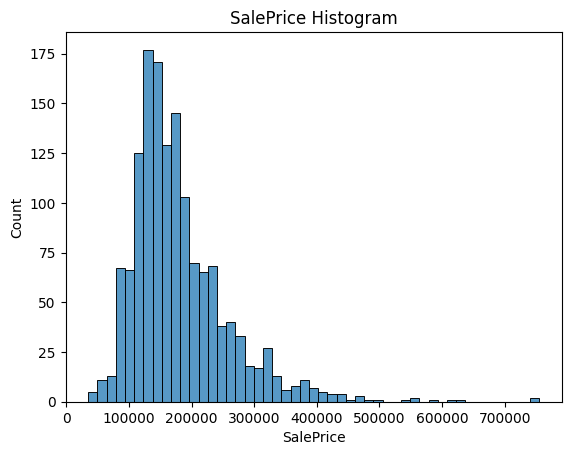

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=train_data,x="SalePrice")
plt.title("SalePrice Histogram")
plt.show()

In [91]:
train_data['SalePrice'].median()

163000.0

In [92]:
correlation=train_data.corr(numeric_only=True)
correlation['SalePrice'].sort_values(ascending=False).head(11)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

[]

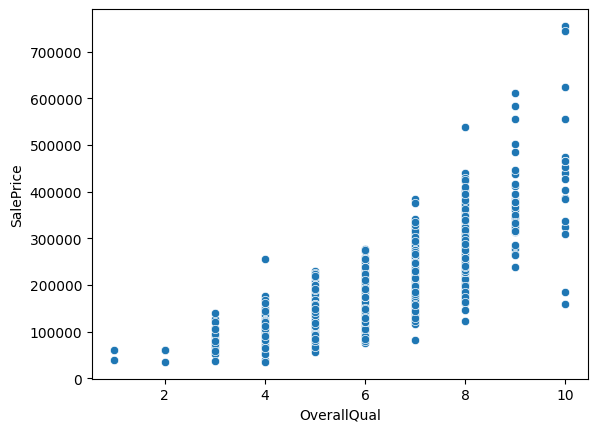

In [93]:
sns.scatterplot(x=train_data['OverallQual'],y=train_data['SalePrice'])
plt.plot()

[]

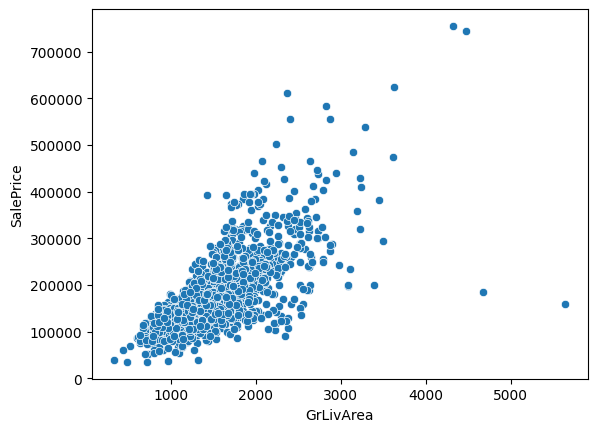

In [94]:
sns.scatterplot(x=train_data['GrLivArea'],y=train_data['SalePrice'])
plt.plot()

[]

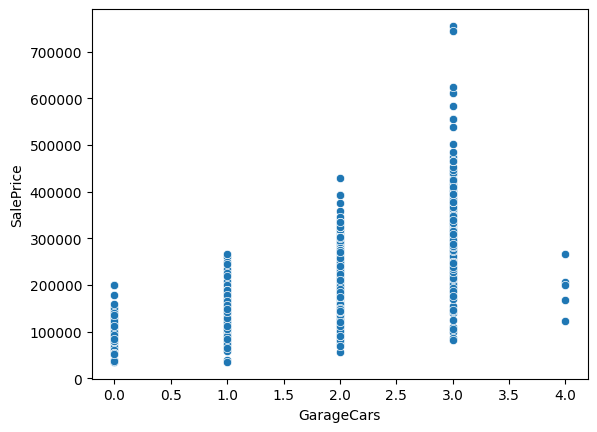

In [95]:
sns.scatterplot(x=train_data['GarageCars'],y=train_data['SalePrice'])
plt.plot()

[]

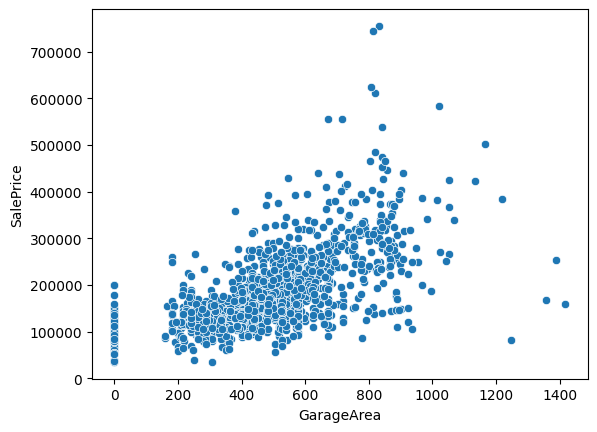

In [96]:
sns.scatterplot(x=train_data['GarageArea'],y=train_data['SalePrice'])
plt.plot()

[]

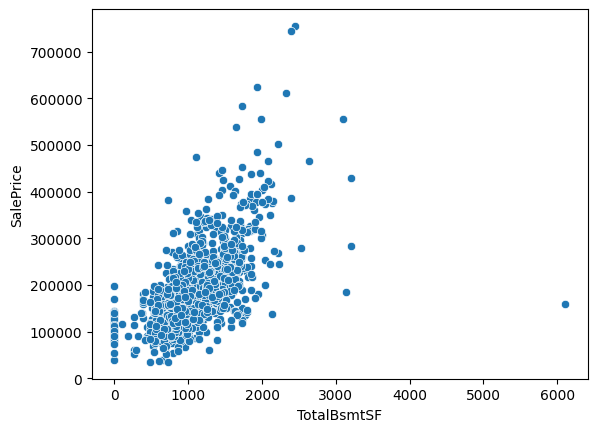

In [97]:
sns.scatterplot(x=train_data['TotalBsmtSF'],y=train_data['SalePrice'])
plt.plot()

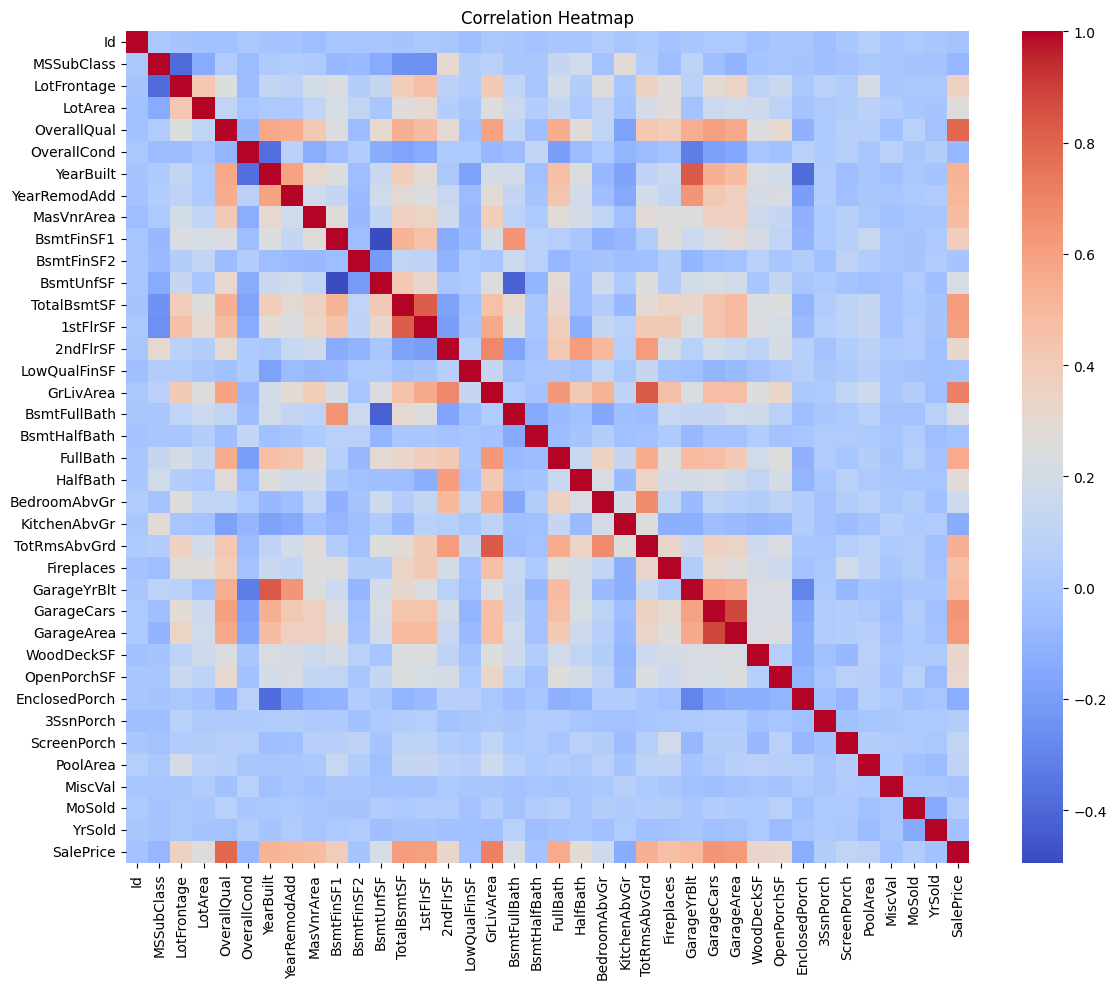

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(train_data.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300)

plt.show()

## 4. Data Cleaning

In [99]:
missing_data=train_data.isnull().sum().sort_values(ascending=False)
missing_data[missing_data>0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [100]:
null_features=['PoolQC',
 'MiscFeature',
 'Alley',
'Fence',
'MasVnrType',
'FireplaceQu',
'LotFrontage',
'GarageQual',
'GarageFinish',
'GarageType',
'GarageYrBlt',
'GarageCond',
'BsmtFinType2',
'BsmtExposure',
'BsmtCond',
'BsmtQual',
'BsmtFinType1',
'MasVnrArea',
'Electrical']

In [101]:
train_data[null_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PoolQC        7 non-null      object 
 1   MiscFeature   54 non-null     object 
 2   Alley         91 non-null     object 
 3   Fence         281 non-null    object 
 4   MasVnrType    588 non-null    object 
 5   FireplaceQu   770 non-null    object 
 6   LotFrontage   1201 non-null   float64
 7   GarageQual    1379 non-null   object 
 8   GarageFinish  1379 non-null   object 
 9   GarageType    1379 non-null   object 
 10  GarageYrBlt   1379 non-null   float64
 11  GarageCond    1379 non-null   object 
 12  BsmtFinType2  1422 non-null   object 
 13  BsmtExposure  1422 non-null   object 
 14  BsmtCond      1423 non-null   object 
 15  BsmtQual      1423 non-null   object 
 16  BsmtFinType1  1423 non-null   object 
 17  MasVnrArea    1452 non-null   float64
 18  Electrical    1459 non-null 

In [102]:
train_data['LotFrontage']=train_data['LotFrontage'].fillna(train_data['LotFrontage'].median())

In [103]:
train_data['MasVnrArea']=train_data['MasVnrArea'].fillna(0)

In [104]:
train_data['MasVnrType']=train_data['MasVnrType'].fillna('None')

In [105]:
train_data[['GarageQual',
'GarageFinish',
'GarageType',
'GarageYrBlt',
'GarageCond',]]=train_data[['GarageQual',
'GarageFinish',
'GarageType',
'GarageYrBlt',
'GarageCond',]].fillna('None')

In [106]:
train_data[['BsmtFinType2',
'BsmtExposure',
'BsmtCond',
'BsmtQual',
'BsmtFinType1']]=train_data[['BsmtFinType2',
'BsmtExposure',
'BsmtCond',
'BsmtQual',
'BsmtFinType1']].fillna("None")

In [107]:
train_data.drop(columns=['PoolQC','MiscFeature'],inplace=True)

In [108]:
train_data['Electrical']=train_data['Electrical'].fillna(train_data['Electrical'].mode()[0])

In [109]:
train_data[['Alley','Fence','FireplaceQu']]=train_data[['Alley','Fence','FireplaceQu']].fillna("None")

## 5. Feature Engineering

[]

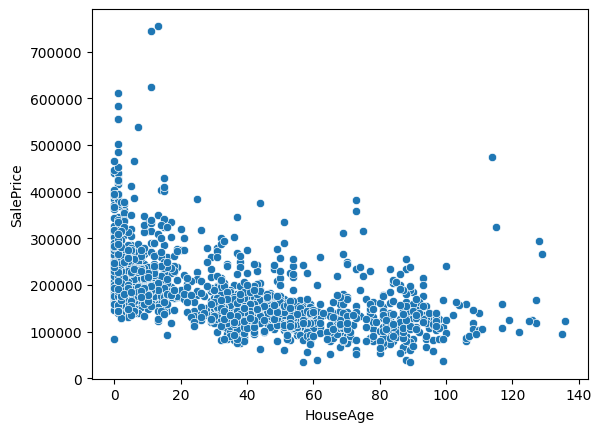

In [110]:
train_data['HouseAge']=train_data['YrSold']- train_data['YearBuilt']

sns.scatterplot(x=train_data['HouseAge'],y=train_data['SalePrice'])
plt.plot()

[]

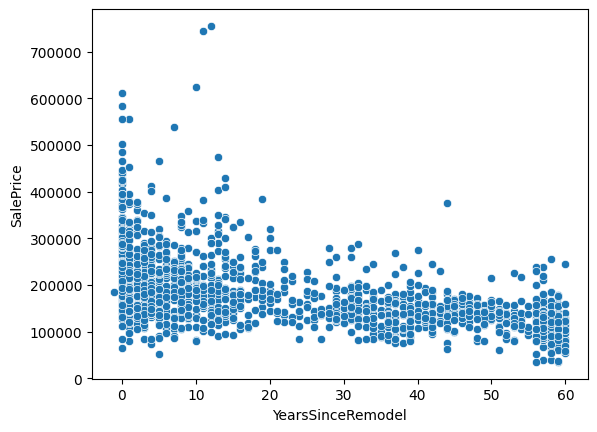

In [111]:
train_data['YearsSinceRemodel']= train_data['YrSold'] - train_data['YearRemodAdd']

sns.scatterplot(x=train_data['YearsSinceRemodel'],y=train_data['SalePrice'])
plt.plot()

In [112]:
train_data['TotalBathrooms']=train_data['BsmtFullBath']+0.5*train_data['BsmtHalfBath']+train_data['FullBath']+0.5*train_data['HalfBath']

[]

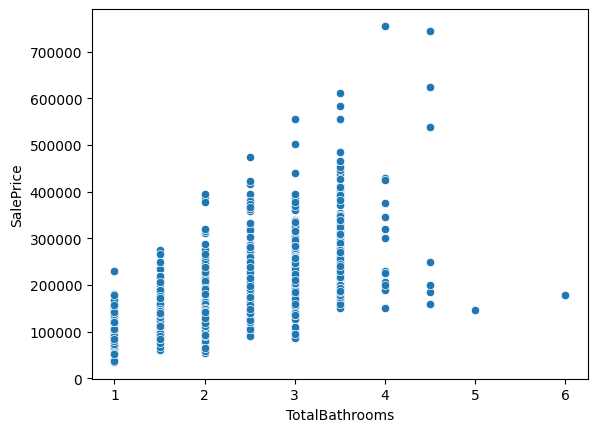

In [113]:
sns.scatterplot(x=train_data['TotalBathrooms'],y=train_data['SalePrice'])
plt.plot()

[]

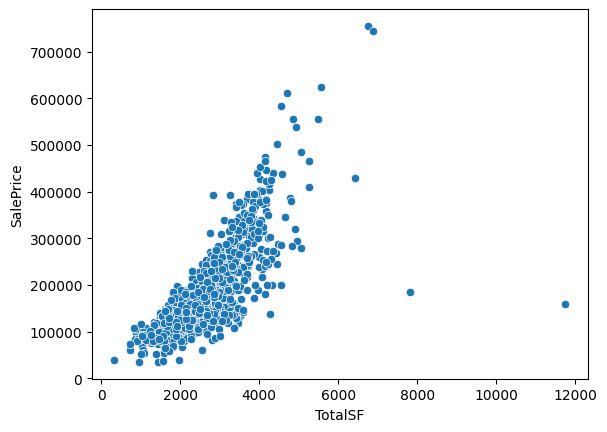

In [114]:
train_data['TotalSF']=train_data['TotalBsmtSF']+train_data['1stFlrSF']+train_data['2ndFlrSF']

sns.scatterplot(x=train_data['TotalSF'],y=train_data['SalePrice'])
plt.plot()

In [115]:
corr1=train_data[['HouseAge','YearsSinceRemodel','TotalSF','SalePrice']].corr()

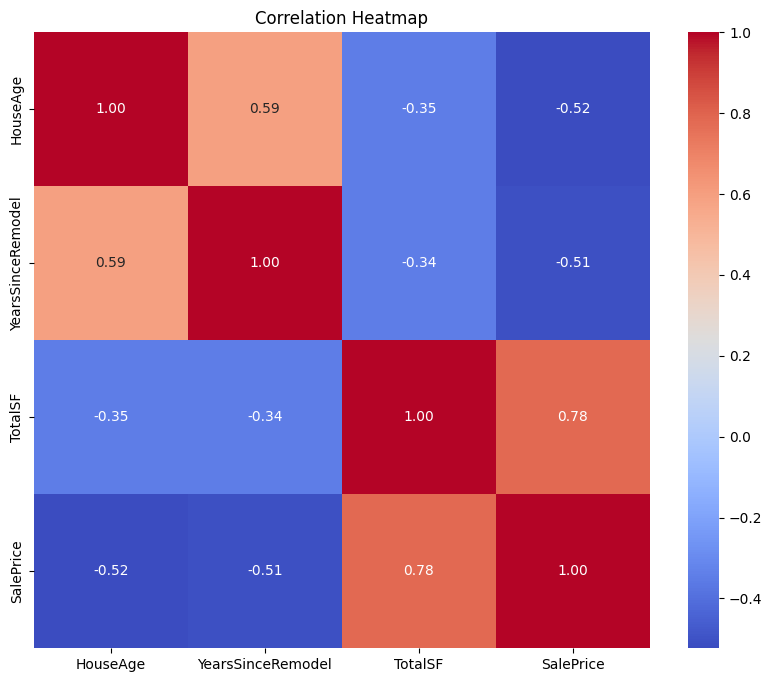

In [116]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr1,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

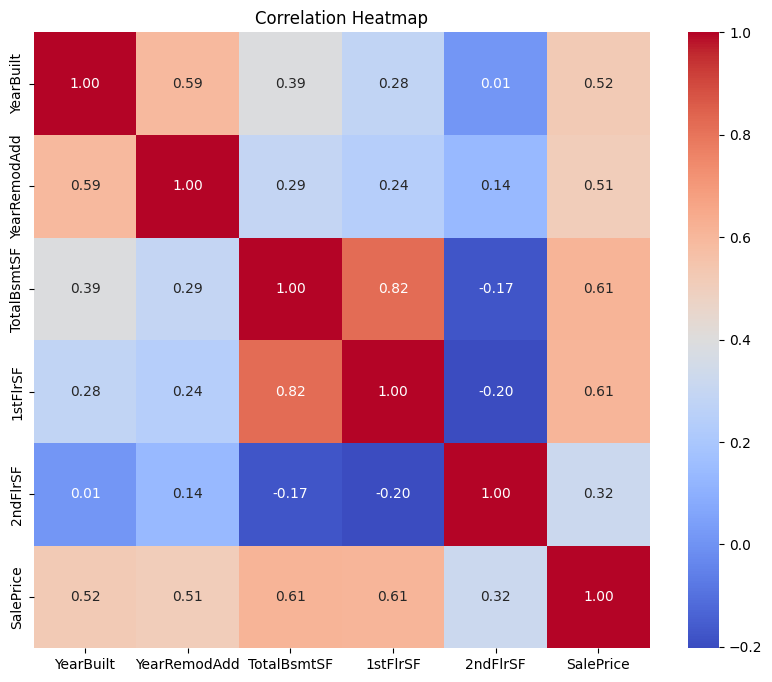

In [117]:
corr2=train_data[['YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF','SalePrice']].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr2,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='GrLivArea'>

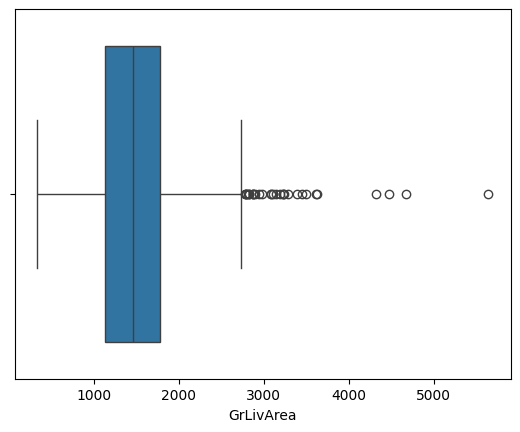

In [118]:
sns.boxplot(x=train_data['GrLivArea'])

In [119]:
train_data[train_data['GrLivArea'] > 4000][['GrLivArea', 'SalePrice']]

,GrLivArea,SalePrice
523,4676,184750
691,4316,755000
1182,4476,745000
1298,5642,160000


In [120]:
train_data.loc[[523, 1298]]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,YearsSinceRemodel,TotalBathrooms,TotalSF
523,524,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,...,0,10,2007,New,Partial,184750,0,-1,4.5,7814
1298,1299,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,...,0,1,2008,New,Partial,160000,0,0,4.5,11752


In [121]:
train_data = train_data.drop(index=[523, 1298])

## 6. Data Preprocessing

In [122]:
train_data['GarageYrBlt'].dtype

dtype('O')

In [123]:
train_data['GarageYrBlt'].unique()[-10:]

array([1952.0, 1928.0, 1922.0, 1934.0, 1906.0, 1914.0, 1946.0, 1908.0,
       1929.0, 1933.0], dtype=object)

In [124]:
train_data.loc[train_data['GarageYrBlt'] == 'None', 'GarageYrBlt'] = 0

In [125]:
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].astype(int)

In [126]:
quality_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

In [127]:
quality_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]

In [128]:
for col in quality_cols:
    train_data[col] = train_data[col].map(quality_map)

In [129]:
lotshape_map = {
    'IR3': 0,
    'IR2': 1,
    'IR1': 2,
    'Reg': 3
}

In [130]:
train_data['LotShape'] = train_data['LotShape'].map(lotshape_map)

In [131]:
bsmt_exp_map = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

In [132]:
train_data['BsmtExposure'] = train_data['BsmtExposure'].map(bsmt_exp_map)

In [133]:
bsmt_fin_map = {
    'None': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

In [134]:
train_data[['BsmtFinType1','BsmtFinType2']] = train_data[['BsmtFinType1','BsmtFinType2']].apply(lambda x: x.map(bsmt_fin_map))

In [135]:
garage_finish_map = {
    'None': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

In [136]:
train_data['GarageFinish'] = train_data['GarageFinish'].map(garage_finish_map)

In [137]:
paved_map = {
    'N': 0,
    'P': 1,
    'Y': 2
}

In [138]:
train_data['PavedDrive'] = train_data['PavedDrive'].map(paved_map)

In [139]:
functional_map = {
    'Sal': 0,
    'Sev': 1,
    'Maj2': 2,
    'Maj1': 3,
    'Mod': 4,
    'Min2': 5,
    'Min1': 6,
    'Typ': 7
}

In [140]:
train_data['Functional'] = train_data['Functional'].map(functional_map)

In [141]:
nominal_cols = [
    'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'CentralAir', 'Electrical',
    'GarageType', 'SaleType', 'SaleCondition','Fence'
]

In [142]:
train_data = pd.get_dummies(
    train_data,
    columns=nominal_cols,
    drop_first=True
)

In [143]:
landslope_map = {
    'Sev': 0,
    'Mod': 1,
    'Gtl': 2
}

train_data['LandSlope'] = train_data['LandSlope'].map(landslope_map)

In [144]:
#log SalePrice
X = train_data.drop("SalePrice", axis=1)
y=np.log1p(train_data['SalePrice'])

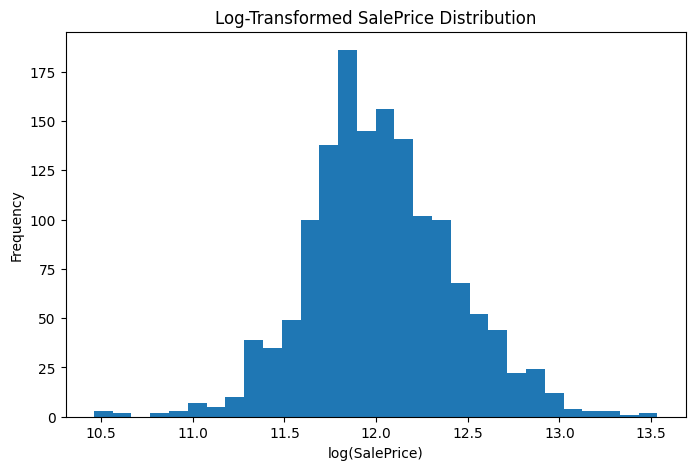

In [145]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=30)
plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("log(SalePrice)")
plt.ylabel("Frequency")
plt.show()

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 7. Baseline Model - Linear Regression

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [148]:
from sklearn.linear_model import LinearRegression

In [149]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [150]:
y_pred = lr.predict(X_test_scaled)

In [151]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

In [152]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.09171669637179485
RMSE: 0.13256500448747927
R²: 0.8957535301310834


## 8. Random Forest

In [153]:
rfr = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [154]:
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [155]:
y_pred_rfr = rfr.predict(X_test)

In [156]:
mae = mean_absolute_error(y_test, y_pred_rfr)
rmse = mean_squared_error(y_test, y_pred_rfr) ** 0.5
r2 = r2_score(y_test, y_pred_rfr)

In [157]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.10631949179179653
RMSE: 0.15882553247086043
R²: 0.8503612004336824


In [158]:
feature_imp = pd.DataFrame({"Feature": X_train.columns,"Importance": rfr.feature_importances_})
feature_imp.sort_values(by="Importance",ascending=False)

,Feature,Importance
6,OverallQual,0.437695
57,TotalSF,0.413123
176,CentralAir_Y,0.014842
40,GarageCars,0.014801
41,GarageArea,0.012171
...,...,...
197,SaleCondition_Family,0.000000
196,SaleCondition_Alloca,0.000000
200,Fence_GdWo,0.000000
201,Fence_MnPrv,0.000000


In [159]:
from sklearn.model_selection import RandomizedSearchCV
rfr_cv = RandomForestRegressor(random_state=42)

param_distr = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 5],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rfr_cv,
    param_distributions=param_distr,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [160]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 5],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2', verbose=2)

In [161]:
print("Best Parameters:",random_search.best_params_)
print("Best CV R²:",random_search.best_score_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV R²: 0.8805041646124565


In [162]:
best_rfr = random_search.best_estimator_

In [163]:
cv_scores = cross_val_score(
    best_rfr,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-validation R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation R² scores: [0.88535807 0.86607189 0.86996998 0.88561415 0.89550674]
Mean CV R²: 0.8805041646124565
Standard Deviation: 0.010899626233894505


In [164]:
y_pred_bestrf = best_rfr.predict(X_test)

In [165]:
mae = mean_absolute_error(y_test, y_pred_bestrf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_bestrf))
r2 = r2_score(y_test, y_pred_bestrf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.09593495636794988
RMSE: 0.1490033991437642
R²: 0.868296921266457


## 9. XGBoost

In [166]:
xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

In [167]:
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [168]:
y_pred_xgb = xgb.predict(X_test)

In [169]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.09853100794001338
RMSE: 0.14343838120289426
R²: 0.8779509717044288


In [170]:
cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_scores = -cv_scores

print("Fold RMSE:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Std Dev:", rmse_scores.std())

Fold RMSE: [0.125883   0.14487235 0.15829239 0.14380694 0.1380639 ]
Mean CV RMSE: 0.14218371649124228
Std Dev: 0.010507512971043468


In [171]:
param_distr_xgb = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 2, 5]
}

In [172]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distr_xgb,
    n_iter=40,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [173]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=200; total time=   0.8s
[CV] END max_depth=10, max_features=None, min_samples_leaf=2, min_samples_split=20, n_estimators=300; total time=   8.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=  16.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500, 700],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [1, 2, 5],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [174]:
print("Best Parameters:",random_search.best_params_)
print("Best CV RMSE:",random_search.best_score_)

Best Parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV RMSE: -0.12154507151351297


In [175]:
best_xgb = random_search.best_estimator_

y_pred_bestxgb = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_bestxgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_bestxgb))
r2 = r2_score(y_test, y_pred_bestxgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.08289651637452784
RMSE: 0.12334194577672722
R²: 0.9097545808854387


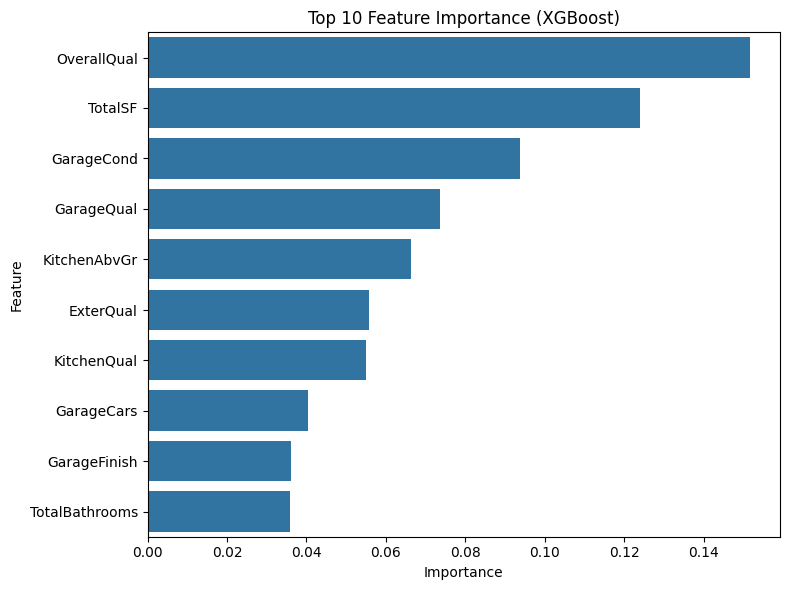

In [176]:
feature_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_imp.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300)
plt.show()

## Preparing the Kaggle Test Dataset

In [177]:
missing_data=test_data.isnull().sum().sort_values(ascending=False)
missing_data[missing_data>0]

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageCond        78
GarageFinish      78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF1         1
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Exterior2nd        1
dtype: int64

In [178]:
test_data['LotFrontage']=test_data['LotFrontage'].fillna(test_data['LotFrontage'].median())

In [179]:
test_data['MasVnrArea']=test_data['MasVnrArea'].fillna(0)

In [180]:
test_data['MasVnrType']=test_data['MasVnrType'].fillna('None')

In [181]:
test_data[['GarageQual',
'GarageFinish',
'GarageType',
'GarageYrBlt',
'GarageCond',]]=test_data[['GarageQual',
'GarageFinish',
'GarageType',
'GarageYrBlt',
'GarageCond',]].fillna('None')

In [182]:
cols = ['BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType1']
test_data.loc[:, cols] = test_data[cols].fillna("None")

In [183]:
test_data.drop(columns=['PoolQC','MiscFeature'],inplace=True)

In [184]:
test_data['Electrical']=test_data['Electrical'].fillna(test_data['Electrical'].mode()[0])

In [185]:
test_data[['Alley','Fence','FireplaceQu']]=test_data[['Alley','Fence','FireplaceQu']].fillna("None")

In [186]:
num_fill_zero = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'GarageCars', 'GarageArea'
]

test_data[num_fill_zero] = test_data[num_fill_zero].fillna(0)

In [187]:
test_data['HouseAge']=test_data['YrSold']- test_data['YearBuilt']
test_data['YearsSinceRemodel']= test_data['YrSold'] - test_data['YearRemodAdd']
test_data['TotalBathrooms']=test_data['BsmtFullBath']+0.5*test_data['BsmtHalfBath']+test_data['FullBath']+0.5*test_data['HalfBath']
test_data['TotalSF']=test_data['TotalBsmtSF']+test_data['1stFlrSF']+test_data['2ndFlrSF']


In [188]:
train_raw = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [189]:
cat_fill_mode = [
    'MSZoning', 'Utilities', 'Functional',
    'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'SaleType'
]

for col in cat_fill_mode:
    test_data[col] = test_data[col].fillna(train_raw[col].mode()[0])

In [190]:
quality_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}
quality_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]
for col in quality_cols:
    test_data[col] = test_data[col].map(quality_map)

In [191]:
lotshape_map = {
    'IR3': 0,
    'IR2': 1,
    'IR1': 2,
    'Reg': 3
}
test_data['LotShape'] = test_data['LotShape'].map(lotshape_map)

In [192]:
bsmt_exp_map = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}
test_data['BsmtExposure'] = test_data['BsmtExposure'].map(bsmt_exp_map)

In [193]:
bsmt_fin_map = {
    'None': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}
test_data[['BsmtFinType1','BsmtFinType2']] = test_data[['BsmtFinType1','BsmtFinType2']].apply(lambda x: x.map(bsmt_fin_map))

In [194]:
garage_finish_map = {
    'None': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}
test_data['GarageFinish'] = test_data['GarageFinish'].map(garage_finish_map)

In [195]:
paved_map = {
    'N': 0,
    'P': 1,
    'Y': 2
}
test_data['PavedDrive'] = test_data['PavedDrive'].map(paved_map)

In [196]:
functional_map = {
    'Sal': 0,
    'Sev': 1,
    'Maj2': 2,
    'Maj1': 3,
    'Mod': 4,
    'Min2': 5,
    'Min1': 6,
    'Typ': 7
}
test_data['Functional'] = test_data['Functional'].map(functional_map)

In [197]:
nominal_cols = [
    'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'CentralAir', 'Electrical',
    'GarageType', 'SaleType', 'SaleCondition','Fence'
]
test_data = pd.get_dummies(
    test_data,
    columns=nominal_cols,
    drop_first=True
)

In [198]:
test_data.select_dtypes(include='object').isnull().sum()

LandSlope      0
GarageYrBlt    0
dtype: int64

In [199]:
landslope_map = {
    'Sev': 0,
    'Mod': 1,
    'Gtl': 2
}
test_data['LandSlope'] = test_data['LandSlope'].map(landslope_map)

In [200]:
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].replace('None', 0)
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].fillna(0)

/tmp/ipykernel_58/1500598610.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data['GarageYrBlt'] = test_data['GarageYrBlt'].replace('None', 0)


In [201]:
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].astype(int)

In [202]:
X_test_kaggle = test_data.reindex(columns=X.columns, fill_value=0)

In [203]:
test_pred_log = best_xgb.predict(X_test_kaggle)

In [204]:
test_pred = np.expm1(test_pred_log)

In [205]:
submission = pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": test_pred
})

In [206]:
submission.to_csv("submission_xgboost.csv", index=False)

 ## 10. LightGBM

In [207]:
lgbm = LGBMRegressor(
    random_state=42,
    verbose=-1
)

In [208]:
lgbm.fit(X_train, y_train)

LGBMRegressor(random_state=42, verbose=-1)

In [209]:
y_pred_lgbm = lgbm.predict(X_test)

In [210]:
mae = mean_absolute_error(y_test, y_pred_lgbm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2 = r2_score(y_test, y_pred_lgbm)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.0882805791036001
RMSE: 0.1335708583459935
R²: 0.8941655617046003


In [211]:
cv_scores_lgbm = cross_val_score(
    lgbm,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_scores = -cv_scores_lgbm

print("Fold RMSE:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Std Dev:", rmse_scores.std())

Fold RMSE: [0.12027189 0.13523993 0.14106302 0.13304748 0.12056556]
Mean CV RMSE: 0.13003757490839699
Std Dev: 0.008279760081906923


In [212]:
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
})

feature_imp = feature_imp.sort_values(
    by='Importance',
    ascending=False
)

feature_imp.head(20)

,Feature,Importance
57,TotalSF,212
3,LotArea,181
41,GarageArea,158
26,GrLivArea,142
0,Id,136
23,1stFlrSF,135
20,BsmtUnfSF,115
17,BsmtFinSF1,101
2,LotFrontage,95
21,TotalBsmtSF,92


In [213]:
param_distr_lgbm = {
    'n_estimators': [200, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 3, 5, 7, 10],
    'min_child_samples': [5, 10, 20, 30],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_distr_lgbm,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_lgbm.fit(X_train, y_train)

print("Best Parameters:", random_search_lgbm.best_params_)
print("Best CV RMSE:", -random_search_lgbm.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=2, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1, subsample=0.9; total time=   0.7s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.1, max_depth=2, min_child_weight=3, n_estimators=700, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0.01, reg_lambda=5, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, reg_alpha=0.01, reg_lambda=5, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max

In [214]:
best_lgbm = random_search_lgbm.best_estimator_

In [215]:
best_lgbm.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.7, learning_rate=0.03, max_depth=3,
              n_estimators=500, random_state=42, subsample=0.8, verbose=-1)

In [216]:
y_pred_lgbm = best_lgbm.predict(X_test)

In [217]:
mae = mean_absolute_error(y_test, y_pred_lgbm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2 = r2_score(y_test, y_pred_lgbm)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.08331412722160854
RMSE: 0.12117132802432948
R²: 0.9129029769914256


In [218]:
test_pred_loglgbm = best_lgbm.predict(X_test_kaggle)
test_pred_lgbm = np.expm1(test_pred_loglgbm)

submission_lgbm = pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": test_pred_lgbm
})

submission_lgbm.to_csv("submission_lightgbm.csv", index=False)

## 11. CatBoost

In [219]:
cat = CatBoostRegressor(
    random_state=42,
    verbose=0
)

In [220]:
cat.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [221]:
y_pred_cat = cat.predict(X_test)

In [222]:
mae = mean_absolute_error(y_test, y_pred_cat)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2 = r2_score(y_test, y_pred_cat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.07642353344902804
RMSE: 0.11758580441517179
R²: 0.9179812087390982


In [223]:
cv_scores_cat = cross_val_score(
    cat,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_scores = -cv_scores_cat

print("Fold RMSE:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Std Dev:", rmse_scores.std())

Fold RMSE: [0.10865206 0.12445875 0.13097249 0.1195379  0.1062141 ]
Mean CV RMSE: 0.11796705951601028
Std Dev: 0.009366451867334142


In [224]:
feature_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat.feature_importances_
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
)

feature_imp.head(20)

,Feature,Importance
57,TotalSF,19.135279
6,OverallQual,12.142775
26,GrLivArea,4.412793
56,TotalBathrooms,3.752808
11,ExterQual,3.217252
41,GarageArea,3.177747
8,YearBuilt,2.712698
3,LotArea,2.710164
33,KitchenQual,2.524571
7,OverallCond,2.456940


In [225]:
param_dist_cat = {
    'iterations': [300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 5, 6, 7, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 0.5, 1, 2],
    'random_strength': [1, 2, 5, 10]
}

random_search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [226]:
random_search_cat.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=-1, min_child_samples=30, n_estimators=500, num_leaves=15, subsample=0.9; total time=   2.5s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=5, min_child_samples=10, n_estimators=200, num_leaves=63, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=3, min_child_samples=10, n_estimators=500, num_leaves=31, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=3, min_child_samples=10, n_estimators=500, num_leaves=31, subsample=1.0; total time=   0.9s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=3, min_child_samples=10, n_estimators=500, num_leaves=31, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=10, min_child_samples=10, n_estimators=700, num_leaves=15, subsample=1.0; total time=   4.0s
[CV] END colsample_by

RandomizedSearchCV(cv=5,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 0.5, 1, 2],
                                        'depth': [4, 5, 6, 7, 8],
                                        'iterations': [300, 500, 700, 1000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'random_strength': [1, 2, 5, 10]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [227]:
print("Best Parameters:", random_search_cat.best_params_)
print("Best CV RMSE:", -random_search_cat.best_score_)

Best Parameters: {'random_strength': 10, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 4, 'bagging_temperature': 2}
Best CV RMSE: 0.11457656697555094


In [228]:
best_cat = random_search_cat.best_estimator_

best_cat.fit(X_train, y_train)

y_pred_bestcat = best_cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_bestcat)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_bestcat))
r2 = r2_score(y_test, y_pred_bestcat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.08027678670344818
RMSE: 0.12338696311084885
R²: 0.9096886933312113


In [229]:
test_pred_logcat = best_cat.predict(X_test_kaggle)

test_pred_cat = np.expm1(test_pred_logcat)

submission_cat = pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": test_pred_cat
})

submission_cat.to_csv("submission_catboost.csv", index=False)

## 12. Ensemble Model

In [230]:
xgb_pred = np.expm1(best_xgb.predict(X_test_kaggle))
lgbm_pred = np.expm1(best_lgbm.predict(X_test_kaggle))
cat_pred = np.expm1(best_cat.predict(X_test_kaggle))

In [231]:
ensemble_pred = (xgb_pred + lgbm_pred) / 2

In [232]:
submission_ensemble = pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": ensemble_pred
})

submission_ensemble.to_csv("submission_ensemble_xgb_lgbm.csv", index=False)

In [233]:
ensemble_pred_all = (xgb_pred + lgbm_pred + cat_pred) / 3

submission = pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": ensemble_pred_all
})

submission.to_csv("submission_ensemble_all.csv", index=False)

## Model Comparison

| Model                           | Validation RMSE | Kaggle Score |
| ------------------------------- | --------------: | -----------: |
| Linear Regression               |          0.1326 |            - |
| Random Forest                   |          0.1490 |            - |
| Tuned XGBoost                   |          0.1233 |      0.13290 |
| Tuned LightGBM                  |          ~0.123 |      0.13144 |
| Tuned CatBoost                  |          0.1234 |      0.13159 |
| **Ensemble (XGB + LGBM + CAT)** |               - |  **0.12781** |


## Conclusion

Three tree-based gradient boosting models were trained and tuned:
- XGBoost
- LightGBM
- CatBoost

Among individual models, LightGBM achieved the best Kaggle score (0.13144).

A simple averaging ensemble of XGBoost, LightGBM, and CatBoost further improved the leaderboard score to **0.12781**, demonstrating the effectiveness of combining diverse models.

The project highlights the importance of data preprocessing, feature engineering, hyperparameter tuning, and ensembling in improving predictive performance.

## Future Work

- Explore additional feature engineering techniques and feature interactions.
- Experiment with weighted averaging and stacking ensembles.
- Optimize hyperparameters using Optuna.
- Train CatBoost using native categorical features.
- Deploy the final model as an interactive Streamlit application.